# PCMCI + ParCorr — All Crops, Monthly

Runs the full preprocessing pipeline and PCMCI + ParCorr on **corn, soybean, and wheat** at monthly frequency.

Three feature sets per crop:
- `climate` — 10 climate variables only
- `climate_rv` — climate + realized volatility
- `macro_news_climate_rv` — full model (all 18 features)

Preprocessing is identical to `eda_preprocessing.ipynb`: interpolate → ffill → Gaussian detrend (15-yr) → anomalize → `pp.trafo2normal`.

## 0. Imports & Configuration

In [15]:
import sys
from pathlib import Path

ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Configuration ─────────────────────────────────────────────────────────────
CROPS     = ['corn', 'soybean', 'wheat']
FREQUENCY = 'monthly'

CYCLE_LEN    = 12                   # months per year
SMOOTH_WIDTH = 15 * CYCLE_LEN       # 15-year Gaussian detrend window
TAU_MAX      = 6                    # from eda_preprocessing.ipynb analysis

print(f'Crops     : {CROPS}')
print(f'Frequency : {FREQUENCY}')
print(f'tau_max   : {TAU_MAX}')
print(f'cycle_len : {CYCLE_LEN}')

Crops     : ['corn', 'soybean', 'wheat']
Frequency : monthly
tau_max   : 6
cycle_len : 12


## 1. Feature Group Definitions

| Group | Variables | N |
|-------|-----------|---|
| `rv` | `weekly_rv` | 1 |
| `climate` | `prcp`, `awnd`, `tmin`, `tmax`, `co2`, `pdsi`, `EVAP`, `soil_moisture_mean_m3m3`, `cloud_cover_mean_pct`, `humidity_mean_pct` | 10 |
| `macro` | `DJIA_Index`, `WTI_Index`, `Broad_Dollar_index`, `Stock_Uncertainty` | 4 |
| `news` | `frbsf_sentiment`, `epu_index`, `Text_Climate_Anomaly` | 3 |

**Feature sets run per crop:**

| Feature Set | Groups | N |
|-------------|--------|---|
| `climate` | climate | 10 |
| `climate_rv` | climate + rv | 11 |
| `macro_news_climate_rv` | macro + news + climate + rv | 18 |

In [16]:
FEATURE_GROUPS = {
    'rv'     : ['weekly_rv'],
    'climate': ['prcp', 'awnd', 'tmin', 'tmax', 'co2', 'pdsi',
                'EVAP', 'soil_moisture_mean_m3m3', 'cloud_cover_mean_pct', 'humidity_mean_pct'],
    'macro'  : ['DJIA_Index', 'WTI_Index', 'Broad_Dollar_index', 'Stock_Uncertainty'],
    'news'   : ['frbsf_sentiment', 'epu_index', 'Text_Climate_Anomaly'],
}

GROUP_COLORS = {
    'rv': '#e41a1c', 'climate': '#377eb8', 'macro': '#4daf4a', 'news': '#984ea3',
}

FEATURE_SETS = {
    'climate'              : ['climate'],
    'climate_rv'           : ['climate', 'rv'],
    'macro_news_climate_rv': ['macro', 'news', 'climate', 'rv'],
}

def build_cols(groups: list[str]) -> list[str]:
    cols: list[str] = []
    for g in groups:
        cols.extend(FEATURE_GROUPS[g])
    return cols

def group_of(col: str) -> str:
    for g, cols in FEATURE_GROUPS.items():
        if col in cols:
            return g
    return 'other'

for name, groups in FEATURE_SETS.items():
    print(f'{name:30s}: {len(build_cols(groups)):2d} vars')

climate                       : 10 vars
climate_rv                    : 11 vars
macro_news_climate_rv         : 18 vars


## 2. Preprocessing & PCMCI Helper Functions

Preprocessing pipeline (identical to `eda_preprocessing.ipynb`):

| Step | Method | Why |
|------|--------|-----|
| Impute | Interpolate `pdsi`/`Broad_Dollar_index`, ffill `DJIA_Index` | Fill isolated gaps before detrending |
| Detrend | `pp.smooth(residuals=True, kernel='gaussian', smooth_width=15yr)` | CO₂/DJIA/Broad Dollar have 10–35% secular drift — removes spurious common-driver links |
| Anomalize | Subtract phase mean, divide by phase std | Annual cycles in temp/precip/EVAP inflate cross-group correlations |
| Gaussianise | `pp.trafo2normal` | 15/18 features non-Gaussian (SW p<0.05); ParCorr t-test null requires Gaussian marginals |

In [17]:
def load_and_preprocess(crop: str, frequency: str) -> tuple[np.ndarray, list[str], pd.Series]:
    """Load CSV, impute, detrend, anomalize, Gaussianise. Returns (arr_normal, col_names, dates)."""
    path = ROOT / 'data' / frequency / f'{crop}.csv'
    raw  = pd.read_csv(path, parse_dates=['date'])
    df   = raw.sort_values('date').reset_index(drop=True)

    # Impute
    for col in ['pdsi', 'Broad_Dollar_index']:
        if col in df.columns:
            df[col] = df[col].interpolate(method='linear', limit_direction='both')
    for col in ['DJIA_Index']:
        if col in df.columns:
            df[col] = df[col].ffill().bfill()
    df = df.dropna().reset_index(drop=True)

    col_names = [c for c in df.columns if c != 'date']
    arr = df[col_names].values.astype(float)

    # Detrend (15-year Gaussian smoother)
    cycle_len    = 52 if frequency == 'weekly' else 12
    smooth_width = 15 * cycle_len
    arr_detrended = pp.smooth(arr, smooth_width=smooth_width, kernel='gaussian', residuals=True)

    # Anomalize
    arr_anom = arr_detrended.copy().astype(float)
    for phase in range(cycle_len):
        idx = slice(phase, None, cycle_len)
        arr_anom[idx] -= arr_detrended[idx].mean(axis=0)
        std = arr_detrended[idx].std(axis=0)
        std[std == 0] = 1.0
        arr_anom[idx] /= std

    # Gaussianise
    arr_normal = pp.trafo2normal(arr_anom)

    return arr_normal, col_names, df['date']


def run_parcorr(
    feature_set_name: str,
    col_names: list[str],
    arr_preprocessed: np.ndarray,
    all_cols: list[str],
    tau_max: int,
    pc_alpha: float = 0.2,
    alpha_level: float = 0.05,
    fdr_method: str = 'fdr_bh',
    max_conds_dim: int | None = None,
    verbosity: int = 0,
) -> dict:
    indices     = [all_cols.index(c) for c in col_names]
    data_subset = arr_preprocessed[:, indices]

    dataframe = pp.DataFrame(
        data_subset,
        var_names=col_names,
        datatime={0: np.arange(len(data_subset))},
    )
    parcorr = ParCorr(significance='analytic')
    pcmci   = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=verbosity)

    results = pcmci.run_pcmci(
        tau_min=1, tau_max=tau_max,
        pc_alpha=pc_alpha, alpha_level=alpha_level,
        fdr_method=fdr_method, max_conds_dim=max_conds_dim,
    )
    q_matrix = pcmci.get_corrected_pvalues(
        p_matrix=results['p_matrix'], tau_max=tau_max, fdr_method=fdr_method,
    )
    graph = pcmci.get_graph_from_pmatrix(
        p_matrix=q_matrix, alpha_level=alpha_level, tau_min=1, tau_max=tau_max,
    )
    results.update({
        'graph': graph, 'q_matrix': q_matrix,
        'pcmci': pcmci, 'col_names': col_names,
    })
    return results


def plot_results(results: dict, title: str, tau_max: int) -> None:
    col_names = results['col_names']
    n = len(col_names)

    tp.plot_graph(
        val_matrix=results['val_matrix'], graph=results['graph'],
        var_names=col_names,
        link_colorbar_label='cross-MCI (ParCorr)', node_colorbar_label='auto-MCI',
        show_autodependency_lags=True,
        figsize=(max(8, n * 0.6), max(6, n * 0.5)),
    )
    plt.suptitle(f'{title}\ntau_max={tau_max} | FDR-BH α=0.05',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

    tp.plot_time_series_graph(
        val_matrix=results['val_matrix'], graph=results['graph'],
        var_names=col_names, link_colorbar_label='MCI',
        figsize=(max(12, n * 0.8), 6),
    )
    plt.suptitle(f'{title} — time-series graph',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()


def extract_rv_links(results: dict, alpha: float = 0.05) -> pd.DataFrame:
    col_names = results['col_names']
    if 'weekly_rv' not in col_names:
        return pd.DataFrame()
    rv_idx  = col_names.index('weekly_rv')
    q_mat   = results['q_matrix']
    val_mat = results['val_matrix']
    rows = [
        {'cause': col_names[j], 'lag': tau, 'val': val_mat[j, rv_idx, tau],
         'q_val': q_mat[j, rv_idx, tau]}
        for j in range(len(col_names))
        for tau in range(1, q_mat.shape[2])
        if q_mat[j, rv_idx, tau] < alpha
    ]
    return pd.DataFrame(rows)


print('Helper functions defined.')

Helper functions defined.


## 3. PCMCI + ParCorr — Parameter Suggestions for All Feature Sets

| Feature Set | N | tau_max | pc_alpha | alpha_level | fdr_method | max_conds_dim | Notes |
|-------------|---|---------|----------|-------------|------------|---------------|-------|
| `climate` | 10 | 6 | 0.2 | 0.05 | `fdr_bh` | `None` | Climate-only causal chain |
| `climate_rv` | 11 | 6 | 0.2 | 0.05 | `fdr_bh` | `None` | Tests climate→RV Granger-causality |
| `macro_rv` | 5 | 6 | 0.2 | 0.05 | `fdr_bh` | `None` | Baseline financial model |
| `macro_news_rv` | 8 | 6 | 0.2 | 0.05 | `fdr_bh` | `None` | Adds news sentiment channel |
| `macro_news_climate_rv` | 18 | 6 | 0.2 | 0.05 | `fdr_bh` | `None` | Full model; matches EDA defaults |

**Rationale:**
- **`tau_max=6`**: Monthly RV auto-bivCI decays below 95% significance at lag ~4; lag 6 adds buffer for slower climate signals (matches `eda_preprocessing.ipynb` Section 12).
- **`pc_alpha=0.2`**: Liberal PC skeleton to preserve MCI step power; final FDR at 0.05 controls false links.
- **`max_conds_dim=None`**: Matches EDA sanity-check default. PC step's own pruning controls conditioning-set size; capping would suppress cross-group links.
- **`significance='analytic'`**: Valid after `trafo2normal`; no permutation cost.

## 4. Run All Crops

For each crop: load → preprocess → run 3 feature sets → plot.


######################################################################
  CROP: CORN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 18)  (2009-04-01 → 2025-03-01)

  ── climate (10 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 2 link(s):
        (co2 -3): pval = 0.04150 | val =  0.353
        (co2 -1): pval = 0.04150 | val =  0.347

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.545
        (prcp -1): pval = 0.00001 | val =  0.466

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.04150 | val =  0.343

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.545

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):


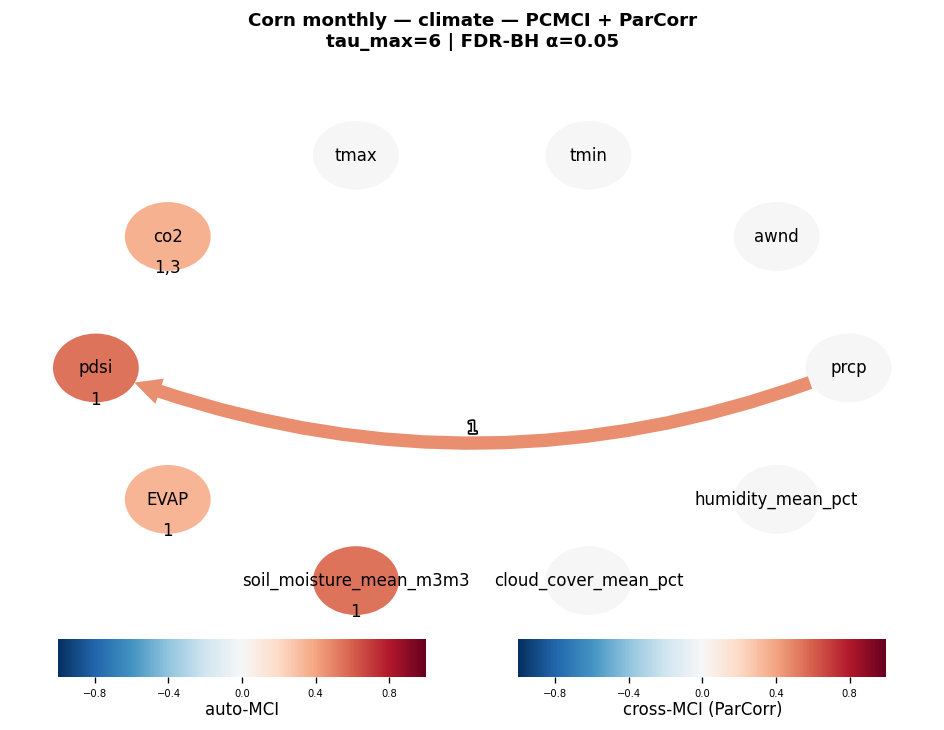

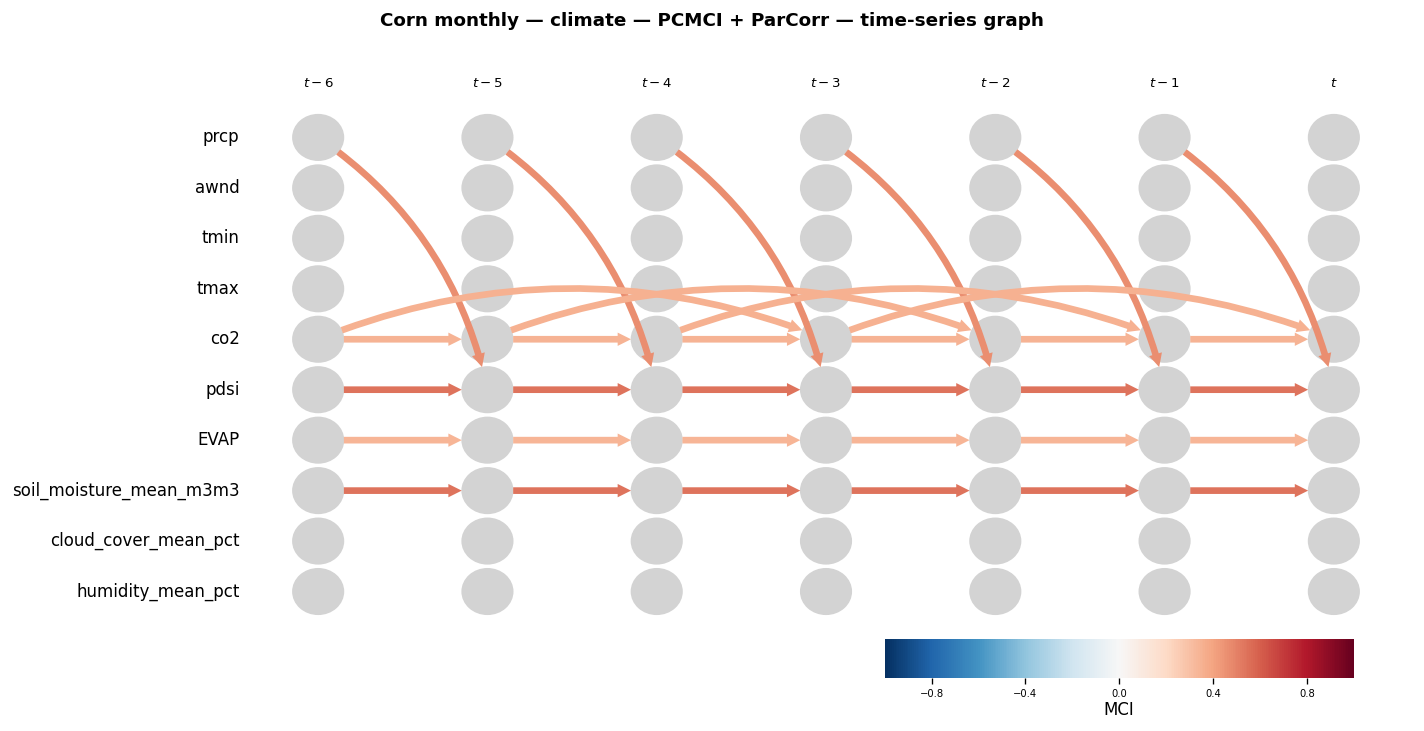


  ── climate_rv (11 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.545
        (prcp -1): pval = 0.00000 | val =  0.481

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.545

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable weekly_rv has 1 link(s):
        (weekly_rv -1): pval = 0.00000 | val =  0.531


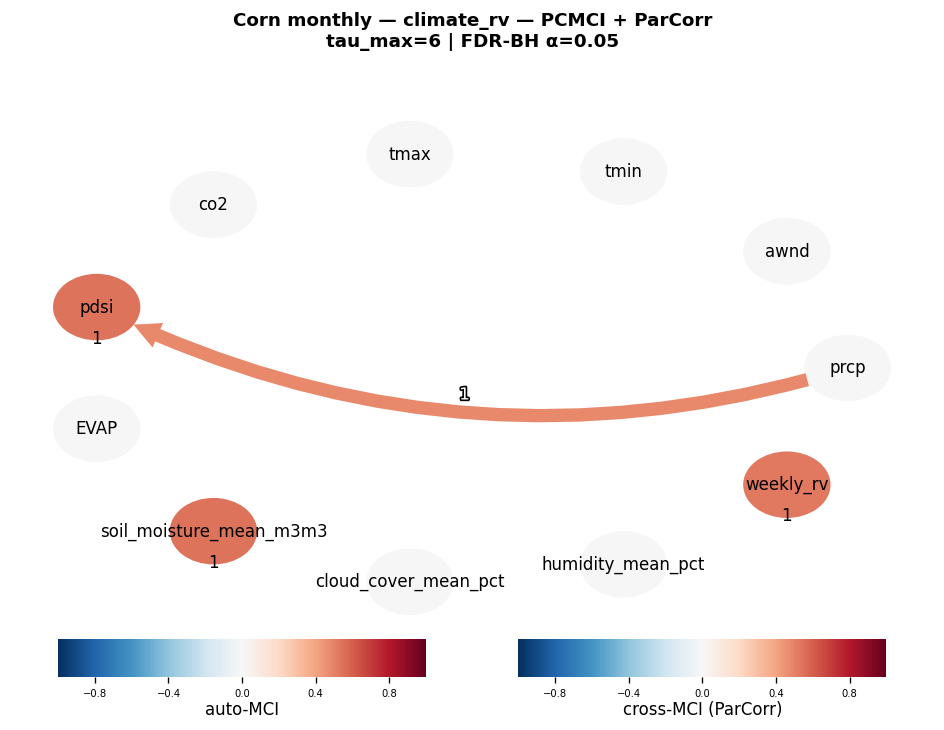

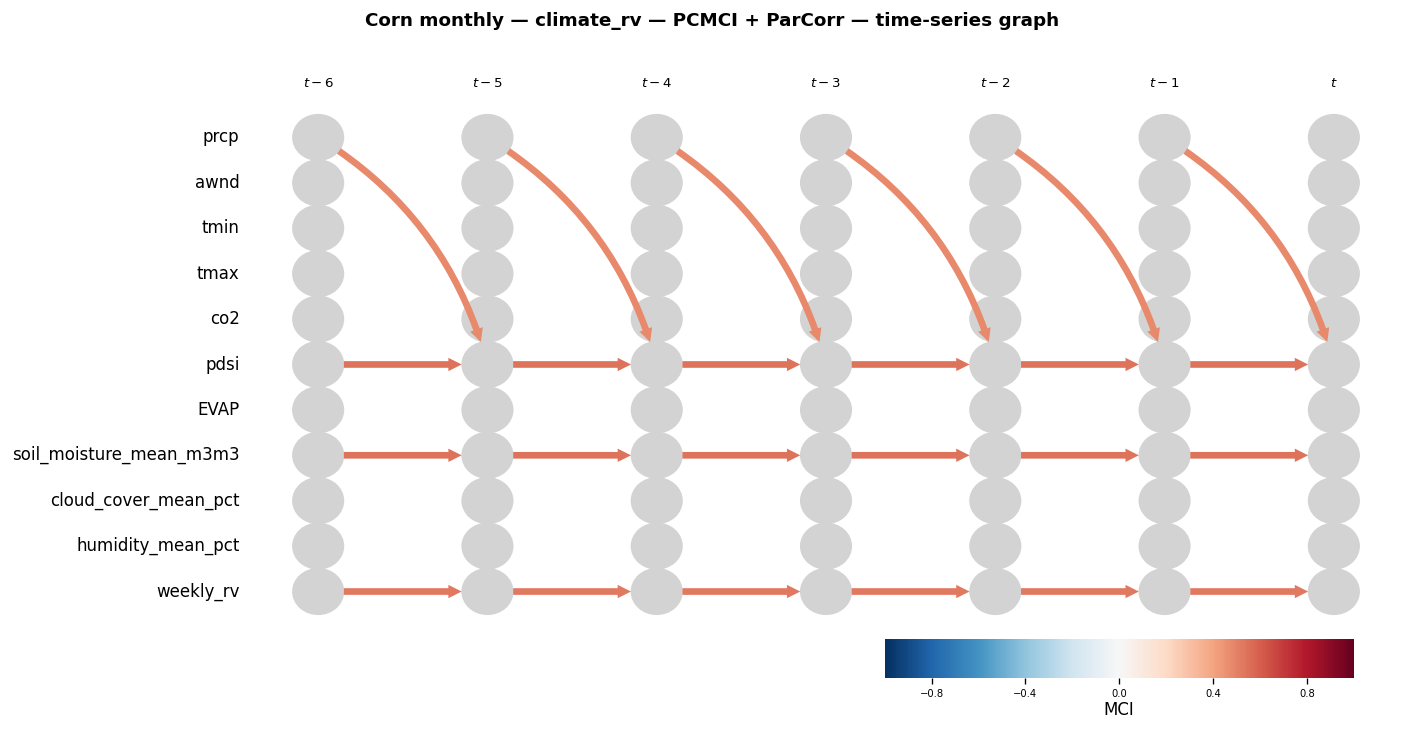


  ── macro_news_climate_rv (18 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 1 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.687

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.696

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.731

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.500

    Variable frbsf_sentiment has 1 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.650

    Variable epu_index has 1 link(s):
        (epu_index -1): pval = 0.00025 | val =  0.432

    Variable Text_Climate_Anomaly has 1 link(s):
        (Text_Climate_Anomaly -1): pval = 0.00305 | val =  0.397

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 2 link(

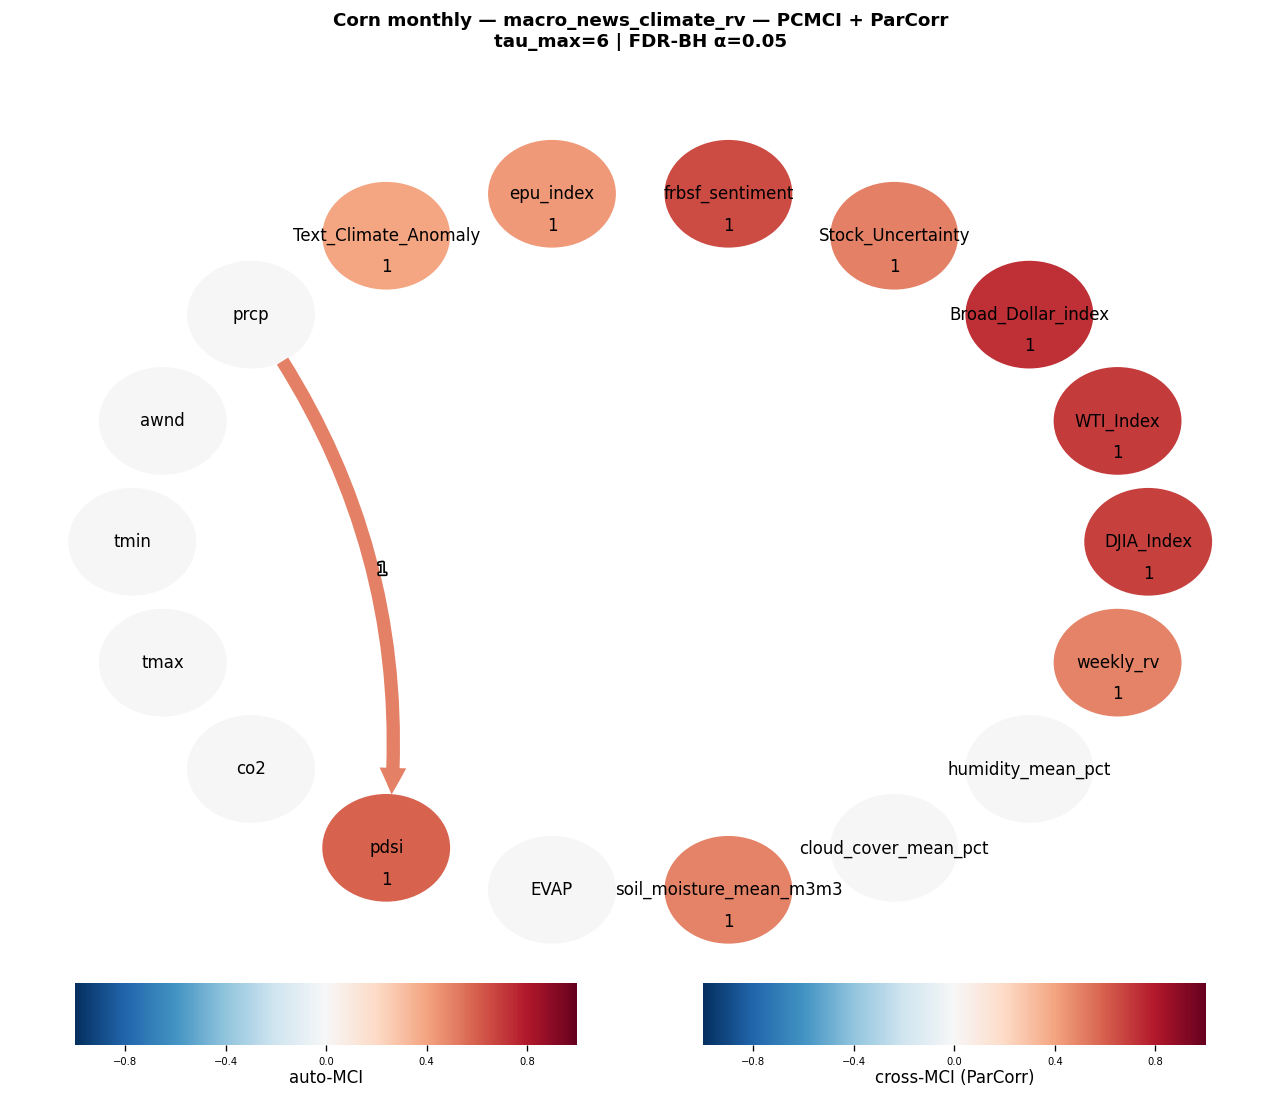

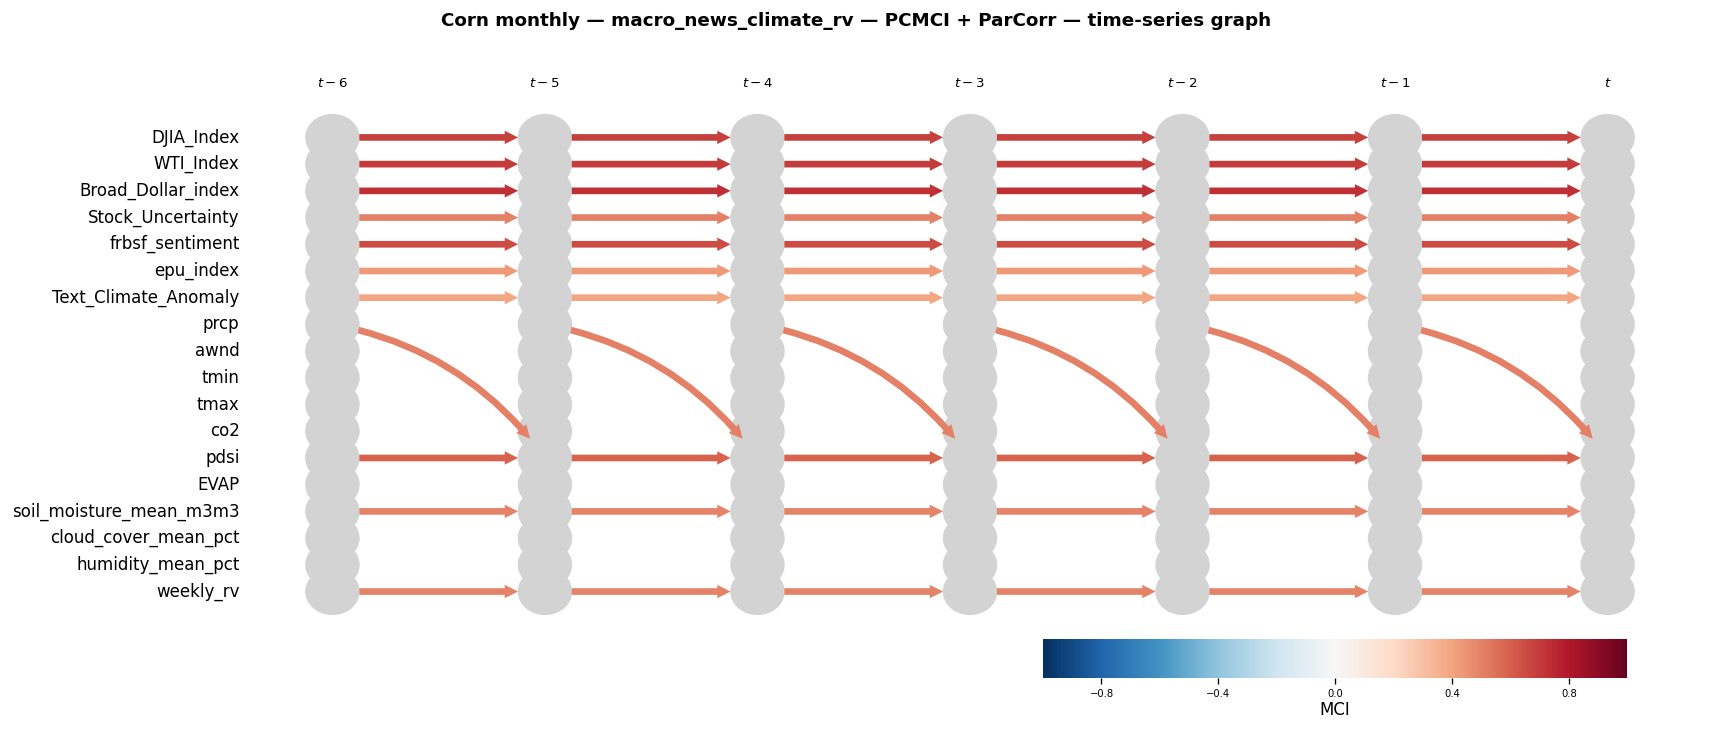


######################################################################
  CROP: SOYBEAN  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 18)  (2009-04-01 → 2025-03-01)

  ── climate (10 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.582
        (prcp -1): pval = 0.00000 | val =  0.480

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.482

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):


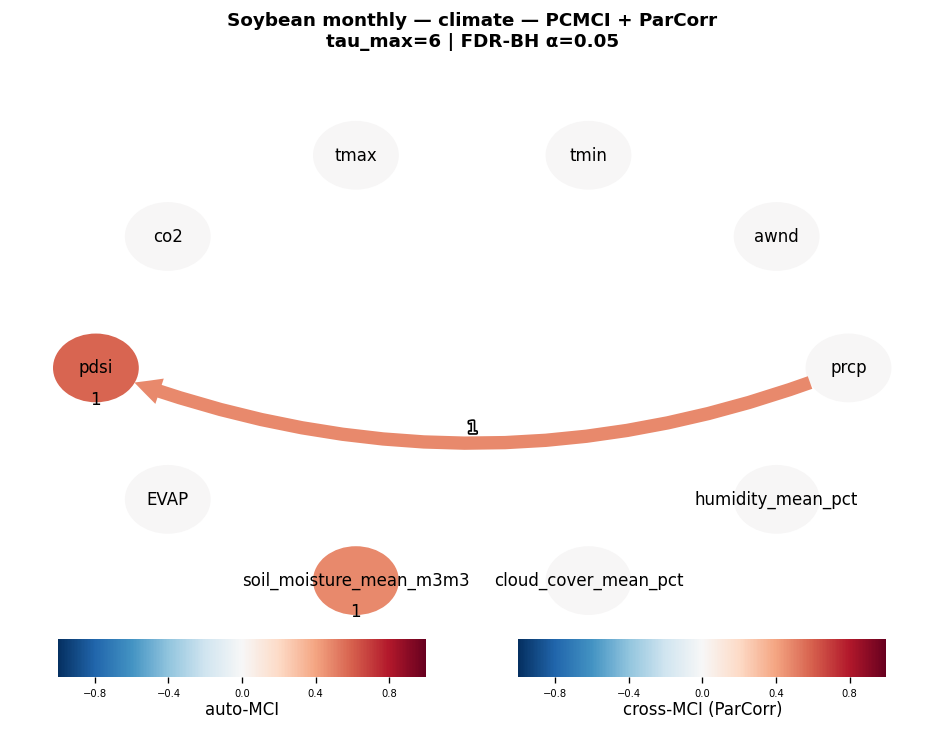

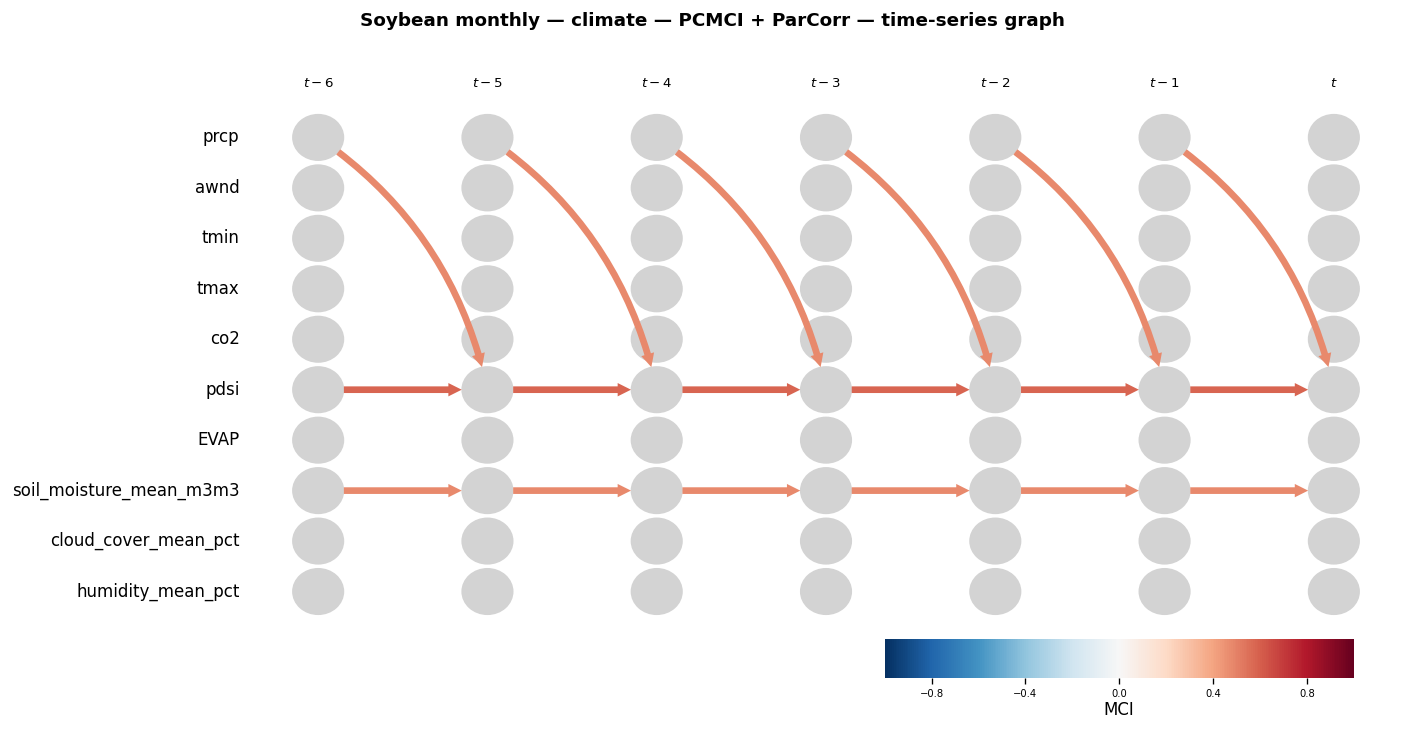


  ── climate_rv (11 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 1 link(s):
        (co2 -3): pval = 0.04995 | val =  0.354

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.00000 | val =  0.582
        (prcp -1): pval = 0.00000 | val =  0.480

    Variable EVAP has 0 link(s):

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.482

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable weekly_rv has 1 link(s):
        (weekly_rv -1): pval = 0.00000 | val =  0.603


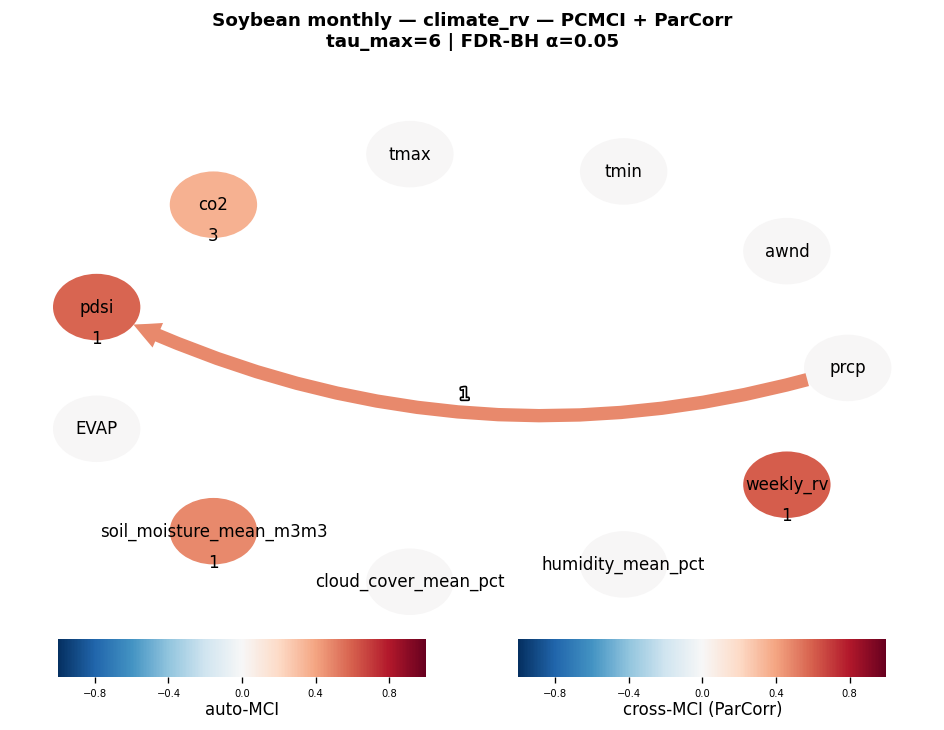

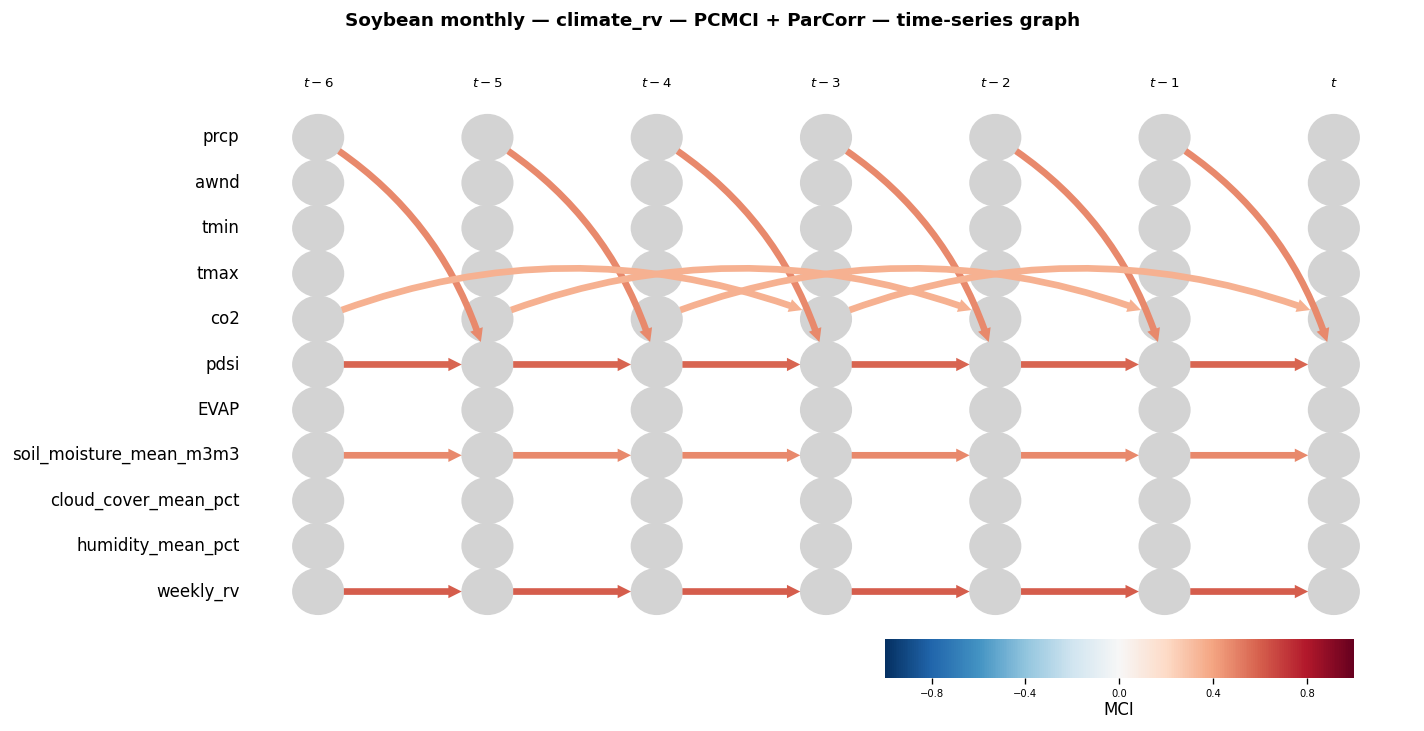


  ── macro_news_climate_rv (18 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 1 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.687

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.695

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.732

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.501

    Variable frbsf_sentiment has 1 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.650

    Variable epu_index has 1 link(s):
        (epu_index -1): pval = 0.00025 | val =  0.432

    Variable Text_Climate_Anomaly has 1 link(s):
        (Text_Climate_Anomaly -1): pval = 0.02014 | val =  0.376

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 2 link(s):
        (co2 -3): pval = 0.033

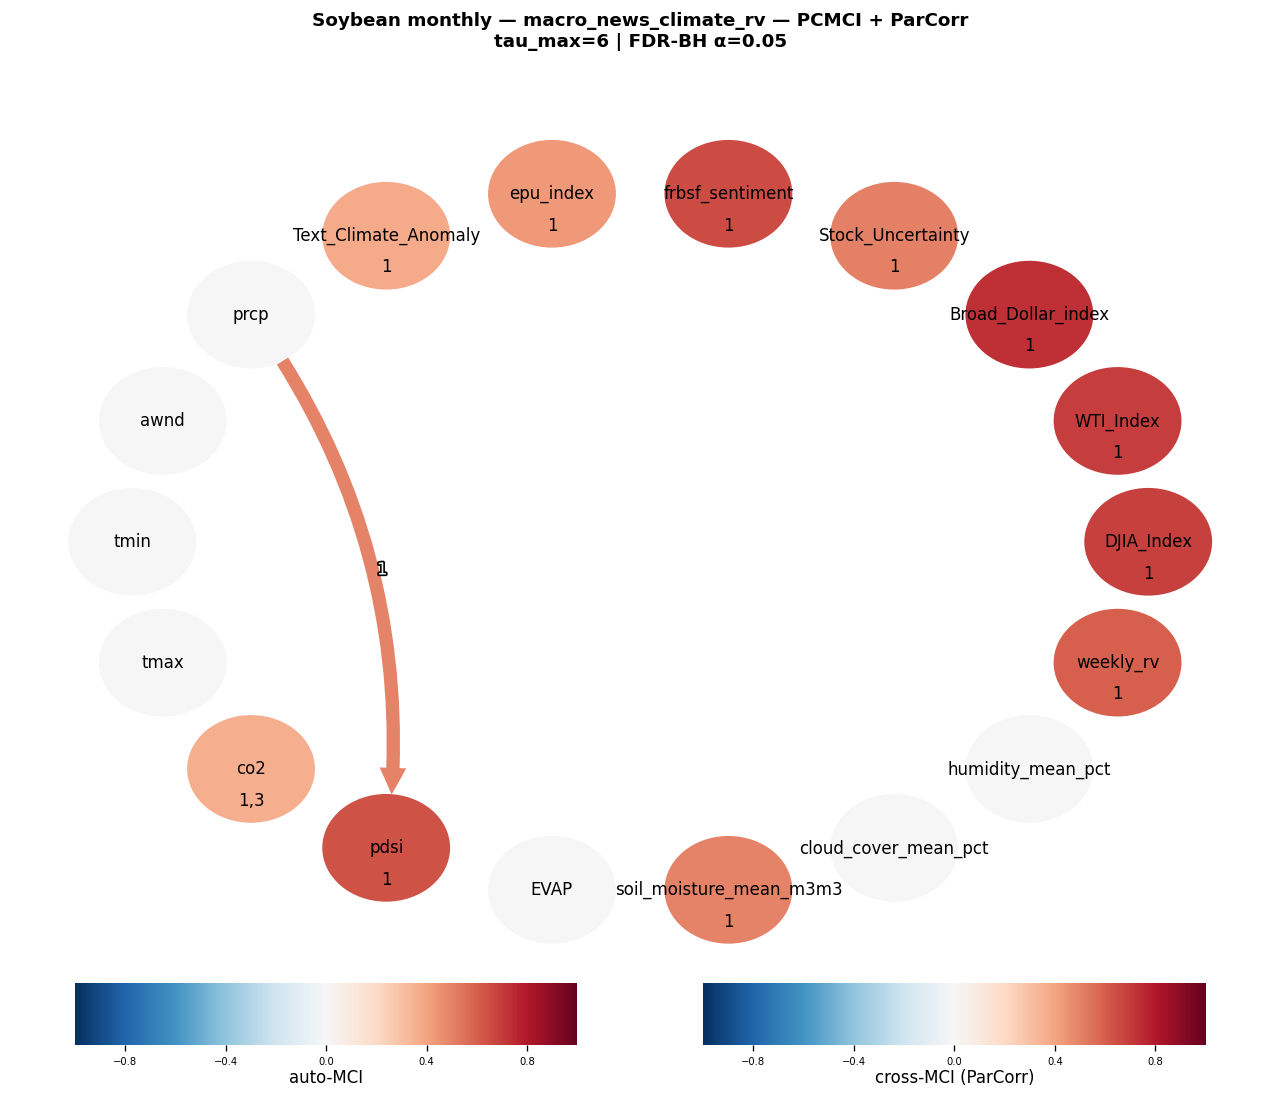

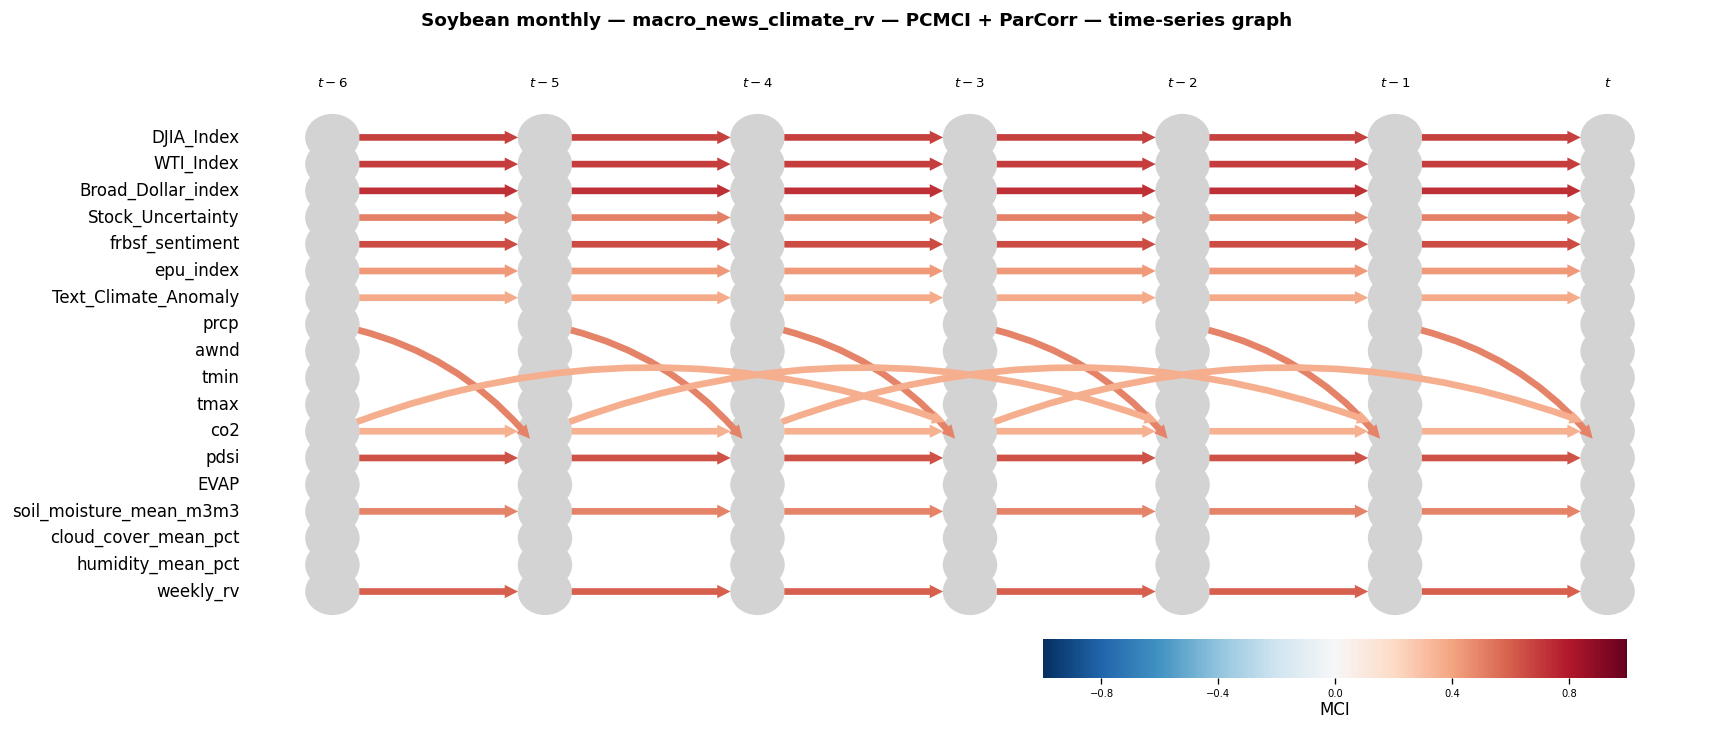


######################################################################
  CROP: WHEAT  |  FREQUENCY: MONTHLY
######################################################################
  Preprocessed: (192, 18)  (2009-04-01 → 2025-03-01)

  ── climate (10 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 2 link(s):
        (co2 -1): pval = 0.02236 | val =  0.354
        (co2 -3): pval = 0.03128 | val =  0.346

    Variable pdsi has 2 link(s):
        (prcp -1): pval = 0.01413 | val =  0.385
        (pdsi -1): pval = 0.01413 | val =  0.384

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.01699 | val =  0.367

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.541

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):


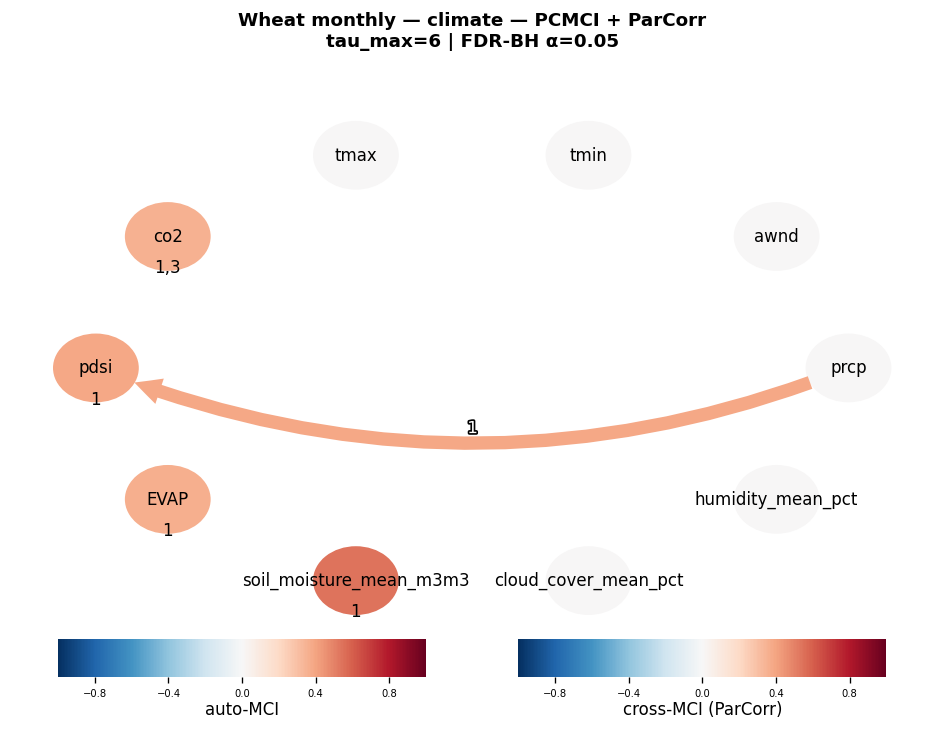

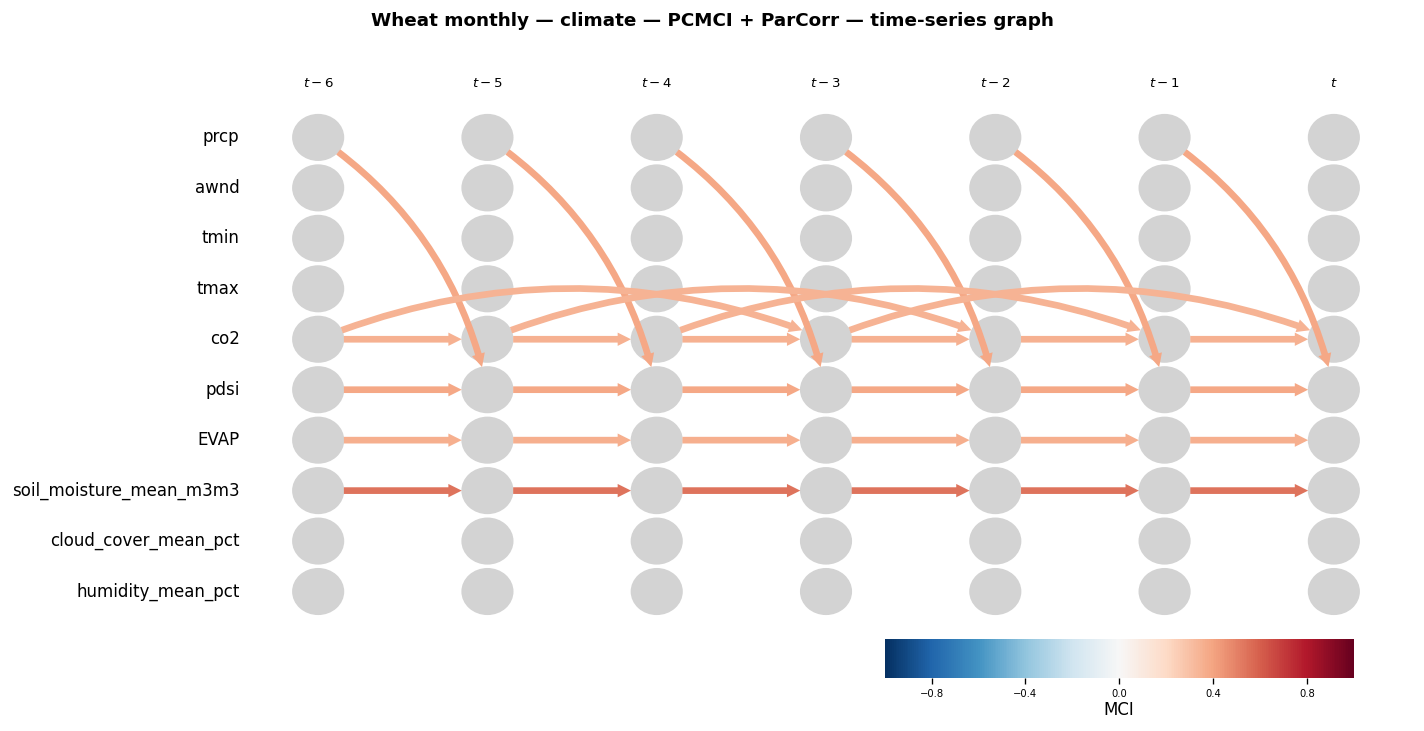


  ── climate_rv (11 vars) ──

## Significant links at alpha = 0.05:

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 2 link(s):
        (prcp -1): pval = 0.01164 | val =  0.385
        (pdsi -1): pval = 0.01164 | val =  0.384

    Variable EVAP has 1 link(s):
        (EVAP -1): pval = 0.01592 | val =  0.367

    Variable soil_moisture_mean_m3m3 has 1 link(s):
        (soil_moisture_mean_m3m3 -1): pval = 0.00000 | val =  0.541

    Variable cloud_cover_mean_pct has 0 link(s):

    Variable humidity_mean_pct has 0 link(s):

    Variable weekly_rv has 1 link(s):
        (weekly_rv -1): pval = 0.00000 | val =  0.638


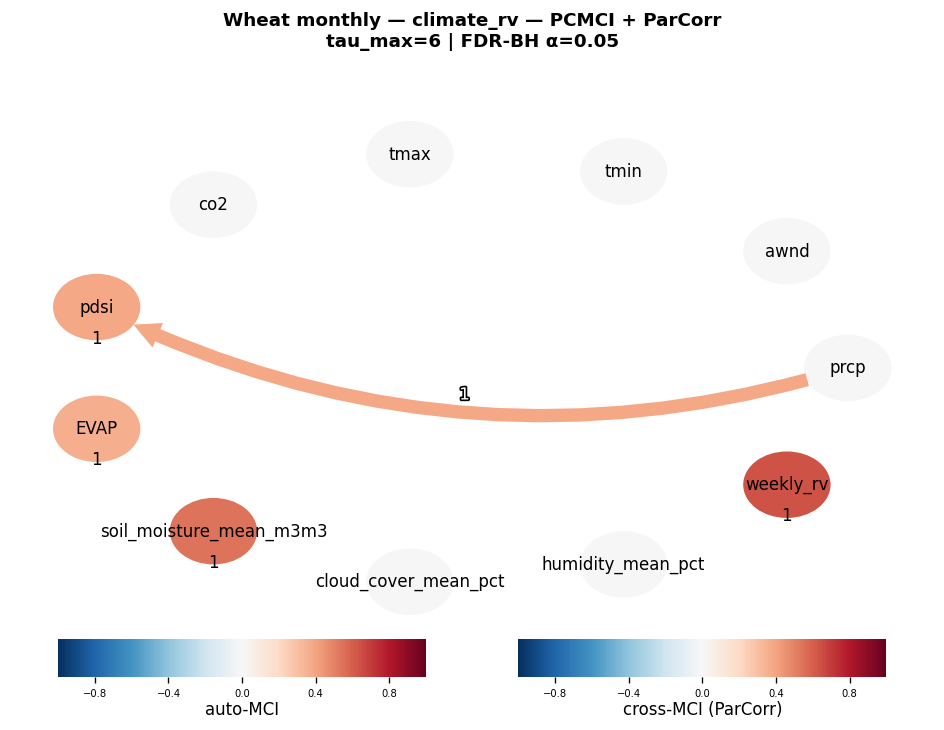

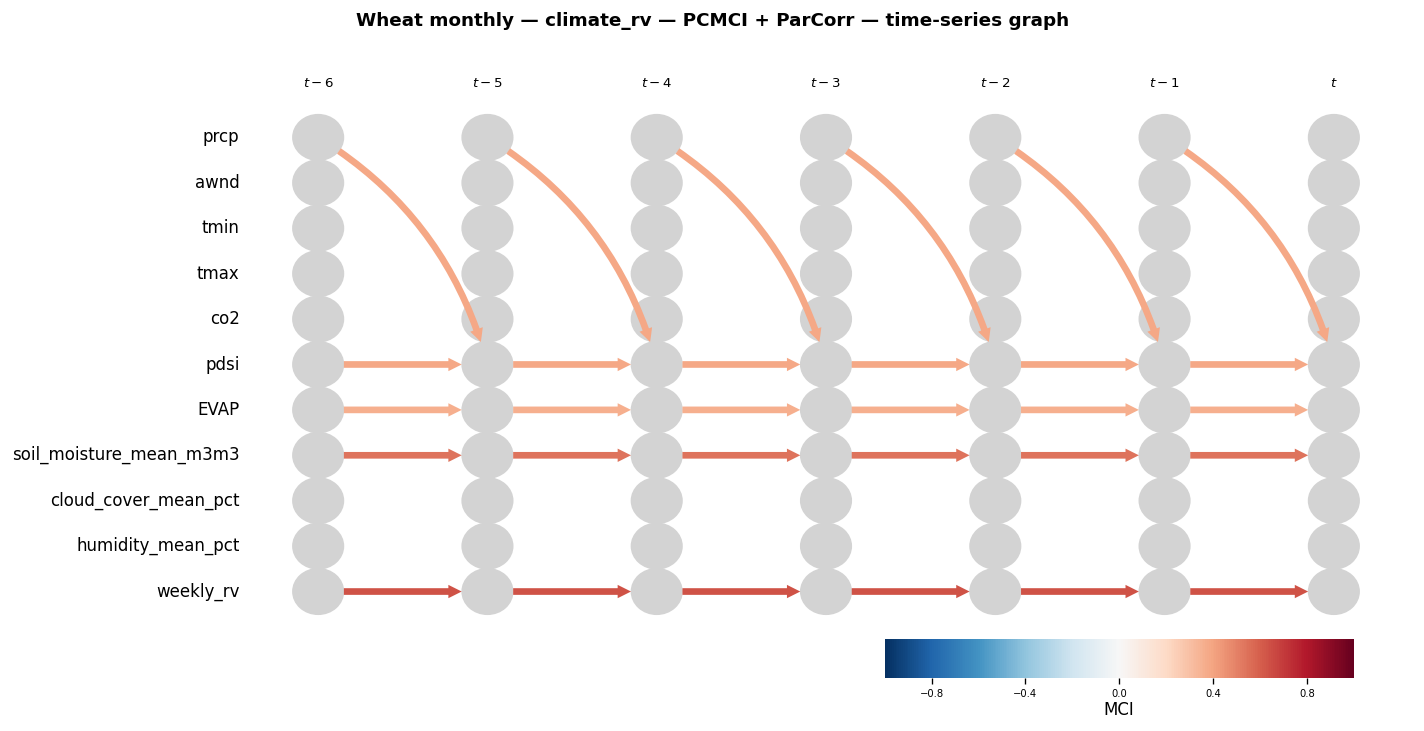


  ── macro_news_climate_rv (18 vars) ──

## Significant links at alpha = 0.05:

    Variable DJIA_Index has 1 link(s):
        (DJIA_Index -1): pval = 0.00000 | val =  0.687

    Variable WTI_Index has 1 link(s):
        (WTI_Index -1): pval = 0.00000 | val =  0.718

    Variable Broad_Dollar_index has 1 link(s):
        (Broad_Dollar_index -1): pval = 0.00000 | val =  0.725

    Variable Stock_Uncertainty has 1 link(s):
        (Stock_Uncertainty -1): pval = 0.00000 | val =  0.486

    Variable frbsf_sentiment has 1 link(s):
        (frbsf_sentiment -1): pval = 0.00000 | val =  0.627

    Variable epu_index has 1 link(s):
        (epu_index -1): pval = 0.00134 | val =  0.418

    Variable Text_Climate_Anomaly has 0 link(s):

    Variable prcp has 0 link(s):

    Variable awnd has 0 link(s):

    Variable tmin has 0 link(s):

    Variable tmax has 0 link(s):

    Variable co2 has 0 link(s):

    Variable pdsi has 2 link(s):
        (pdsi -1): pval = 0.01648 | val =  0.384
        (prc

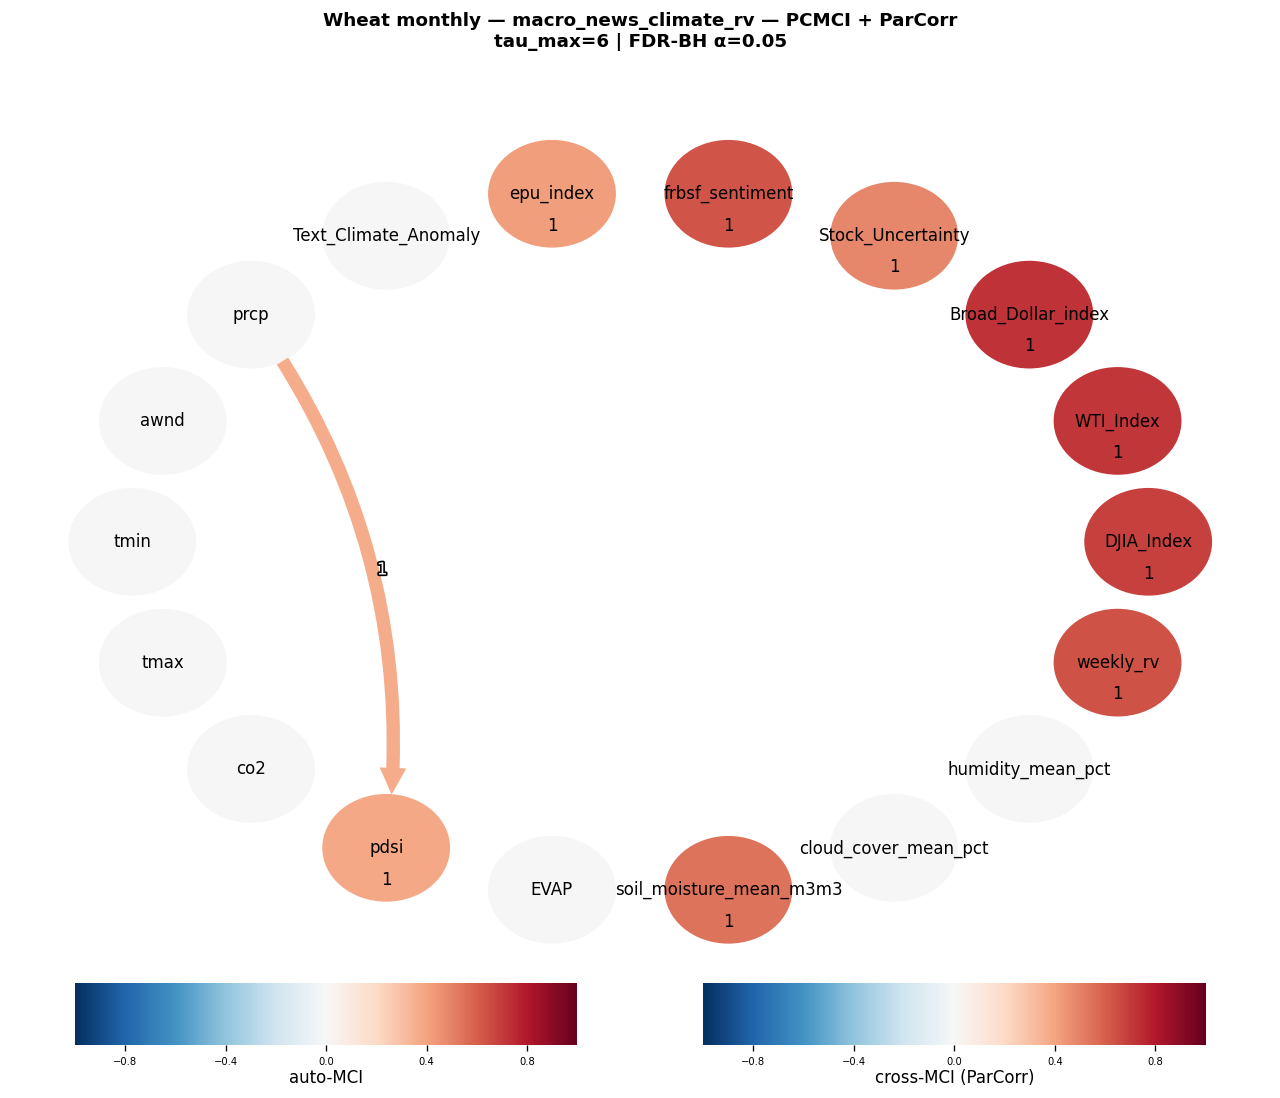

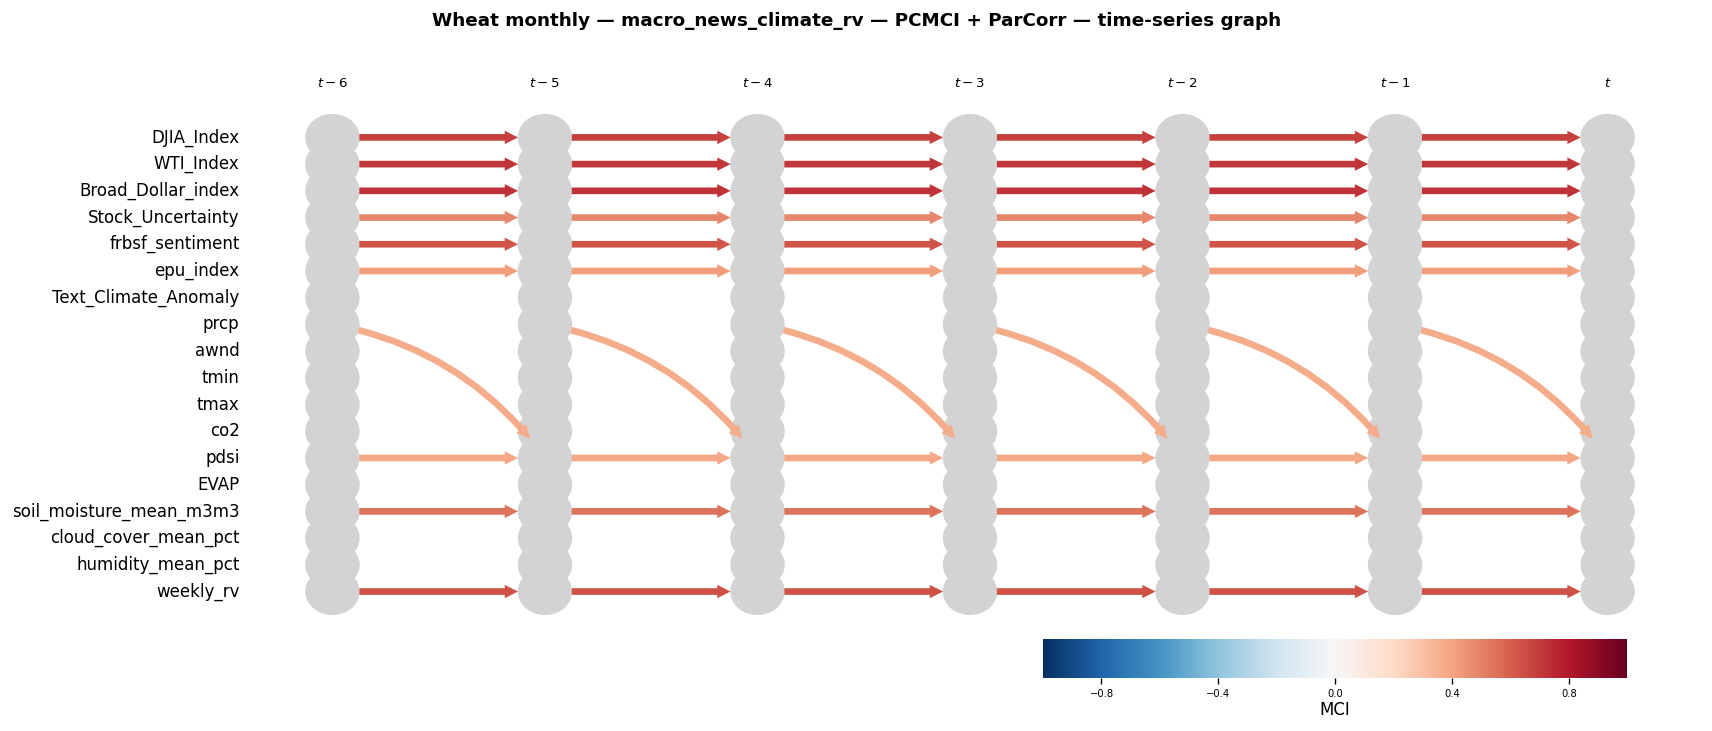


All crops done.


In [18]:
# Stores all results: all_results[crop][feature_set_name] = results dict
all_results: dict[str, dict] = {}

for crop in CROPS:
    print(f'\n{"#"*70}')
    print(f'  CROP: {crop.upper()}  |  FREQUENCY: {FREQUENCY.upper()}')
    print(f'{"#"*70}')

    arr_normal, all_cols, dates = load_and_preprocess(crop, FREQUENCY)
    print(f'  Preprocessed: {arr_normal.shape}  '
          f'({dates.min().date()} → {dates.max().date()})')

    all_results[crop] = {}

    for fs_name, groups in FEATURE_SETS.items():
        col_names = build_cols(groups)
        # Only keep columns that are present in this dataset
        col_names = [c for c in col_names if c in all_cols]

        print(f'\n  ── {fs_name} ({len(col_names)} vars) ──')

        res = run_parcorr(
            feature_set_name=fs_name,
            col_names=col_names,
            arr_preprocessed=arr_normal,
            all_cols=all_cols,
            tau_max=TAU_MAX,
            pc_alpha=0.2,
            alpha_level=0.05,
            fdr_method='fdr_bh',
            max_conds_dim=None,
            verbosity=0,
        )
        all_results[crop][fs_name] = res

        res['pcmci'].print_significant_links(
            p_matrix=res['q_matrix'],
            val_matrix=res['val_matrix'],
            alpha_level=0.05,
        )

        plot_results(
            res,
            title=f'{crop.capitalize()} {FREQUENCY} — {fs_name} — PCMCI + ParCorr',
            tau_max=TAU_MAX,
        )

print('\nAll crops done.')

## 5. Cross-Crop Comparison: Significant Links into `weekly_rv`

Summary of what Granger-causes RV for each crop, from the `climate_rv` and `macro_news_climate_rv` feature sets.

In [19]:
for fs_name in ['climate_rv', 'macro_news_climate_rv']:
    print(f'\n{"="*65}')
    print(f'  Feature set: {fs_name}')
    print(f'{"="*65}')
    for crop in CROPS:
        links = extract_rv_links(all_results[crop][fs_name])
        print(f'\n  {crop.upper()}:')
        if links.empty:
            print('    No significant links into weekly_rv.')
        else:
            print(links.sort_values('q_val').to_string(index=False,
                  float_format='{:.3f}'.format, col_space=18))


  Feature set: climate_rv

  CORN:
             cause                lag                val              q_val
         weekly_rv                  1              0.531              0.000

  SOYBEAN:
             cause                lag                val              q_val
         weekly_rv                  1              0.603              0.000

  WHEAT:
             cause                lag                val              q_val
         weekly_rv                  1              0.638              0.000

  Feature set: macro_news_climate_rv

  CORN:
             cause                lag                val              q_val
         weekly_rv                  1              0.499              0.000

  SOYBEAN:
             cause                lag                val              q_val
         weekly_rv                  1              0.597              0.000

  WHEAT:
             cause                lag                val              q_val
         weekly_rv                  1

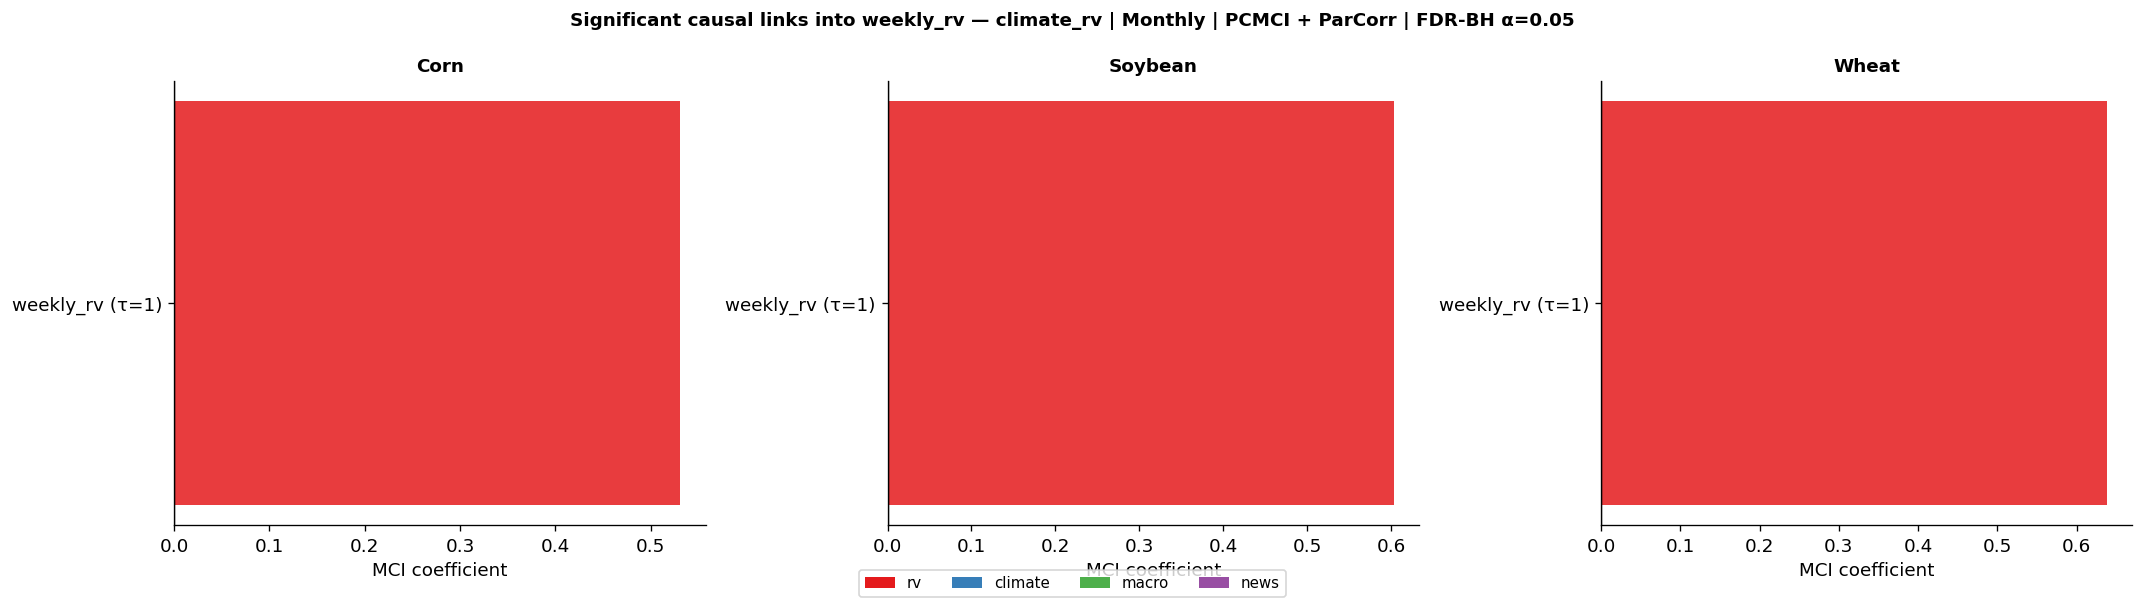

In [20]:
# ── Bar chart comparison: MCI into weekly_rv, climate_rv feature set ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, crop in zip(axes, CROPS):
    links = extract_rv_links(all_results[crop]['climate_rv'])
    if links.empty:
        ax.set_title(f'{crop.capitalize()}\n(no significant links)', fontsize=10)
        continue
    labels = [f"{r['cause']} (τ={r['lag']})" for _, r in links.iterrows()]
    vals   = links['val'].values
    colors = [GROUP_COLORS.get(group_of(r['cause']), '#888') for _, r in links.iterrows()]
    ax.barh(labels, vals, color=colors, alpha=0.85)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('MCI coefficient')
    ax.set_title(f'{crop.capitalize()}', fontsize=11, fontweight='bold')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9)
fig.suptitle(
    f'Significant causal links into weekly_rv — climate_rv | {FREQUENCY.capitalize()} | PCMCI + ParCorr | FDR-BH α=0.05',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

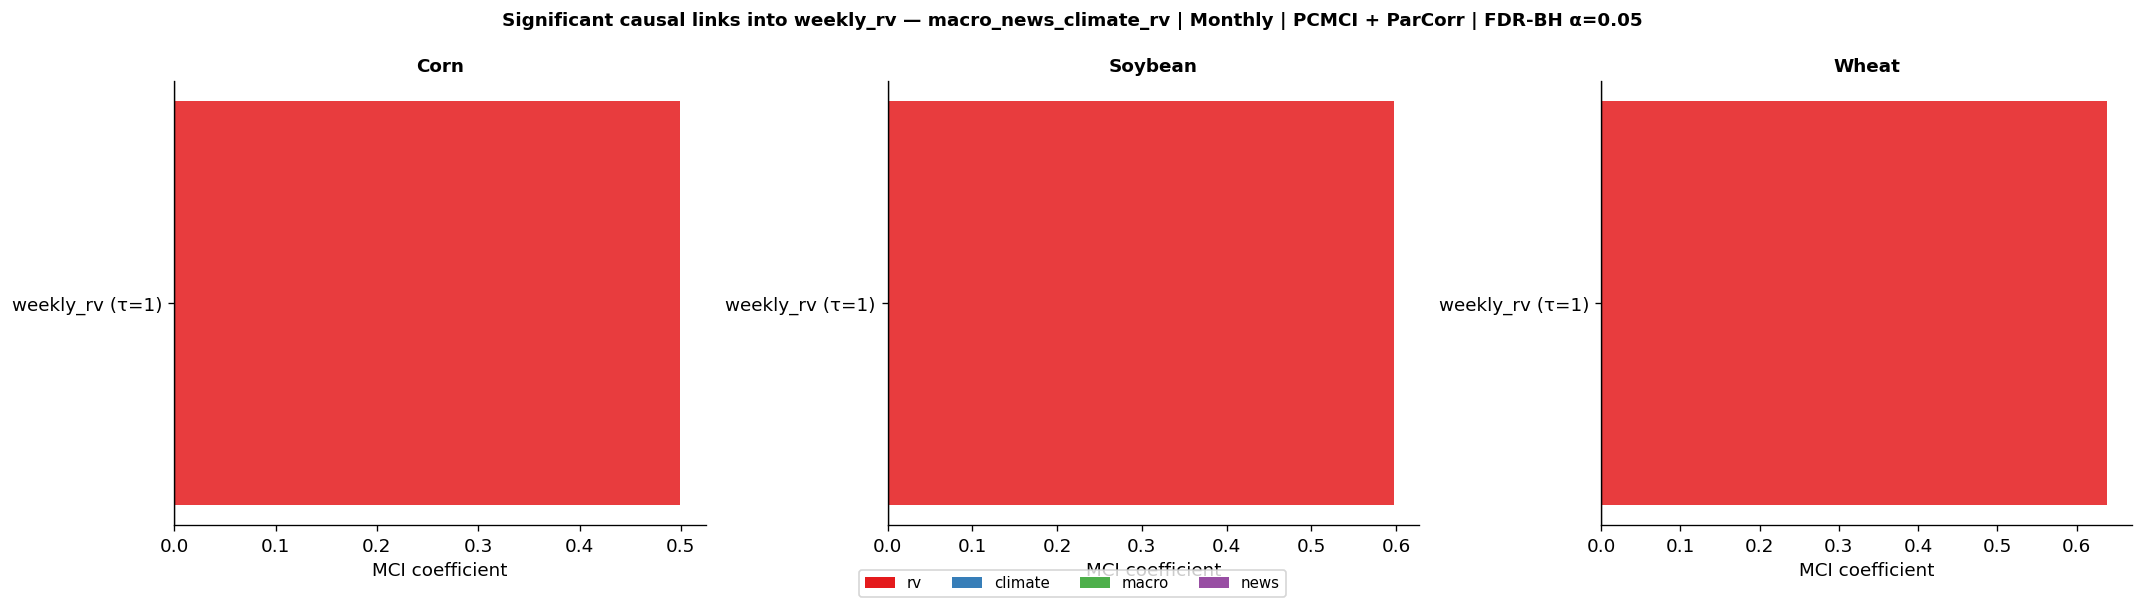

In [21]:
# ── Same chart for macro_news_climate_rv feature set ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, crop in zip(axes, CROPS):
    links = extract_rv_links(all_results[crop]['macro_news_climate_rv'])
    if links.empty:
        ax.set_title(f'{crop.capitalize()}\n(no significant links)', fontsize=10)
        continue
    labels = [f"{r['cause']} (τ={r['lag']})" for _, r in links.iterrows()]
    vals   = links['val'].values
    colors = [GROUP_COLORS.get(group_of(r['cause']), '#888') for _, r in links.iterrows()]
    ax.barh(labels, vals, color=colors, alpha=0.85)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel('MCI coefficient')
    ax.set_title(f'{crop.capitalize()}', fontsize=11, fontweight='bold')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

handles = [Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9)
fig.suptitle(
    f'Significant causal links into weekly_rv — macro_news_climate_rv | {FREQUENCY.capitalize()} | PCMCI + ParCorr | FDR-BH α=0.05',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.show()

## 6. Summary

**Crops:** corn, soybean, wheat  
**Frequency:** monthly  
**Feature sets per crop:** climate (10), climate_rv (11), macro_news_climate_rv (18)

**Preprocessing (identical to `eda_preprocessing.ipynb`):**
- Interpolate `pdsi`, `Broad_Dollar_index` | ffill `DJIA_Index`
- `pp.smooth(smooth_width=180, kernel='gaussian', residuals=True)` — 15-yr detrend
- Anomalize: phase-wise mean/std removal (cycle_length=12)
- `pp.trafo2normal` — rank-based Gaussianisation

**PCMCI + ParCorr config:**
- `tau_min=1`, `tau_max=6`, `pc_alpha=0.2`
- `alpha_level=0.05`, `fdr_method='fdr_bh'`, `max_conds_dim=None`
- `significance='analytic'`

**Next steps:** cross-validate with GPDCtorch (nonlinear additive) and FAISSCMI (nonparametric).